# EDA: Title + Review Text for Rating Prediction

This notebook analyzes the Womens Clothing E-Commerce Reviews dataset with focus on only 3 columns used for modeling:
1. **Title**
2. **Review Text**
3. **Rating**

The notebook compares these fields across stages: raw data, cleaned data, and train/val/test splits.

**Important note:** all "word count" statistics in this notebook are computed with whitespace split (`str.split().str.len()`), not subword tokenizer length (BPE/WordPiece).

If split files are missing, run:

```bash
python scripts/prepare_data.py
```

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and data/")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EDA_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "eda"
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_current_figure(filename: str, dpi: int = 200) -> Path:
    output_path = EDA_FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", output_path.relative_to(PROJECT_ROOT))
    return output_path

print("Project root:", PROJECT_ROOT)
print("EDA figure dir:", EDA_FIGURES_DIR)

Project root: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL
EDA figure dir: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL\outputs\figures\eda


In [2]:
from src import config
from src.preprocessing import load_raw_data, clean_data, create_full_text

print("RAW_CSV:", config.RAW_CSV)
print("DATA_SPLITS_DIR:", config.DATA_SPLITS_DIR)
print("MIN_TOKEN_LENGTH:", config.MIN_TOKEN_LENGTH)

RAW_CSV: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL\data\raw\Womens Clothing E-Commerce Reviews.csv
DATA_SPLITS_DIR: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL\data\splits
MIN_TOKEN_LENGTH: 3


## 1) Before Prepare Data (Raw CSV)

In [3]:
raw_path = Path(config.RAW_CSV)
raw_original = pd.read_csv(raw_path, index_col=0)

print("Raw shape:", raw_original.shape)
display(raw_original.head(5))

Raw shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [19]:
raw_focus = raw_original[["Title", "Review Text", "Rating"]].copy()

raw_profile = pd.DataFrame({
    "dtype": raw_focus.dtypes.astype(str),
    "missing": raw_focus.isna().sum(),
    "missing_pct": (raw_focus.isna().mean() * 100).round(2),
    "n_unique": raw_focus.nunique(dropna=True),
}).sort_values(["missing", "n_unique"], ascending=[False, False])

display(raw_profile)

,dtype,missing,missing_pct,n_unique
Title,object,3810,16.22,13993
Review Text,object,845,3.60,22634
Rating,int64,0,0.00,5


Saved figure: outputs\figures\eda\raw_rating_review_token_by_rating.png


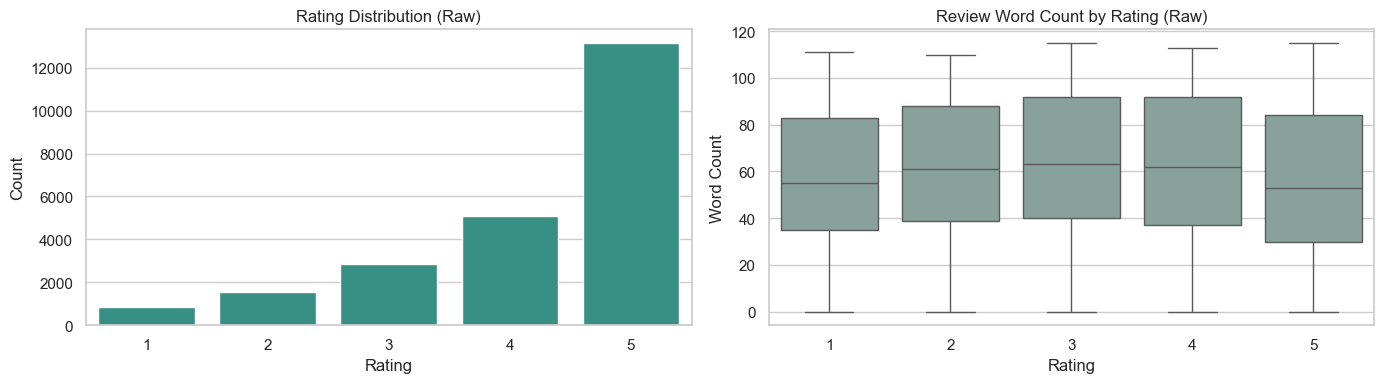

In [11]:
rating_series = pd.to_numeric(raw_original["Rating"], errors="coerce")
review_word_count_raw = raw_original["Review Text"].fillna("").astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rating_order = sorted(rating_series.dropna().astype(int).unique().tolist())
sns.countplot(x=rating_series.dropna().astype(int), order=rating_order, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Rating Distribution (Raw)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

tmp = pd.DataFrame({
    "rating": rating_series,
    "review_word_count": review_word_count_raw,
}).dropna()
tmp["rating"] = tmp["rating"].astype(int)
sns.boxplot(data=tmp, x="rating", y="review_word_count", ax=axes[1], color="#84a59d")
axes[1].set_title("Review Word Count by Rating (Raw)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
save_current_figure("raw_rating_review_token_by_rating.png")
plt.show()

,count,mean,std,min,50%,75%,90%,95%,max
review_char_len,23486.0,297.581666,152.572686,0.0,292.0,451.0,500.0,500.0,508.0
review_word_count,23486.0,58.030869,30.176433,0.0,57.0,87.0,98.0,101.0,115.0
title_char_len,23486.0,15.998808,11.244639,0.0,15.0,23.0,31.0,37.0,52.0
title_word_count,23486.0,2.802052,2.055155,0.0,3.0,4.0,6.0,7.0,12.0


Empty title ratio: 16.22%
Empty review ratio: 3.60%
Saved figure: outputs\figures\eda\raw_title_review_token_length.png


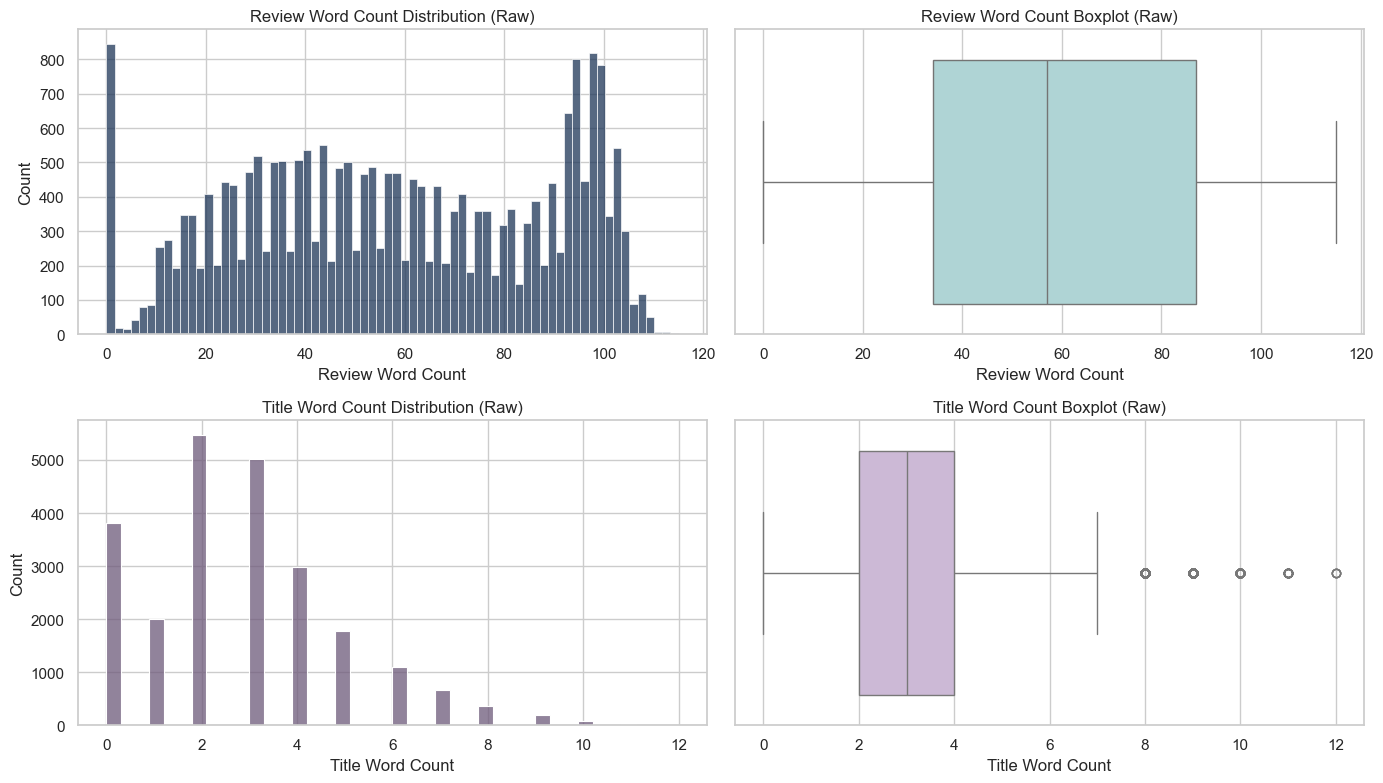

In [12]:
review_text_raw = raw_original["Review Text"].fillna("").astype(str)
title_text_raw = raw_original["Title"].fillna("").astype(str)

raw_text_stats = pd.DataFrame({
    "review_char_len": review_text_raw.str.len(),
    "review_word_count": review_text_raw.str.split().str.len(),
    "title_char_len": title_text_raw.str.len(),
    "title_word_count": title_text_raw.str.split().str.len(),
})

display(raw_text_stats.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T)
print(f"Empty title ratio: {(title_text_raw.str.strip() == '').mean() * 100:.2f}%")
print(f"Empty review ratio: {(review_text_raw.str.strip() == '').mean() * 100:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.histplot(raw_text_stats["review_word_count"], bins=70, ax=axes[0, 0], color="#1d3557")
axes[0, 0].set_title("Review Word Count Distribution (Raw)")
axes[0, 0].set_xlabel("Review Word Count")

sns.boxplot(x=raw_text_stats["review_word_count"], ax=axes[0, 1], color="#a8dadc")
axes[0, 1].set_title("Review Word Count Boxplot (Raw)")
axes[0, 1].set_xlabel("Review Word Count")

sns.histplot(raw_text_stats["title_word_count"], bins=40, ax=axes[1, 0], color="#6d597a")
axes[1, 0].set_title("Title Word Count Distribution (Raw)")
axes[1, 0].set_xlabel("Title Word Count")

sns.boxplot(x=raw_text_stats["title_word_count"], ax=axes[1, 1], color="#cdb4db")
axes[1, 1].set_title("Title Word Count Boxplot (Raw)")
axes[1, 1].set_xlabel("Title Word Count")

plt.tight_layout()
save_current_figure("raw_title_review_token_length.png")
plt.show()

,missing_title,missing_review
rating,,
1,17.93,2.49
2,13.10,1.02
3,14.18,1.67
4,15.52,3.33
5,17.20,4.50


Saved figure: outputs\figures\eda\raw_missing_and_token_gap.png


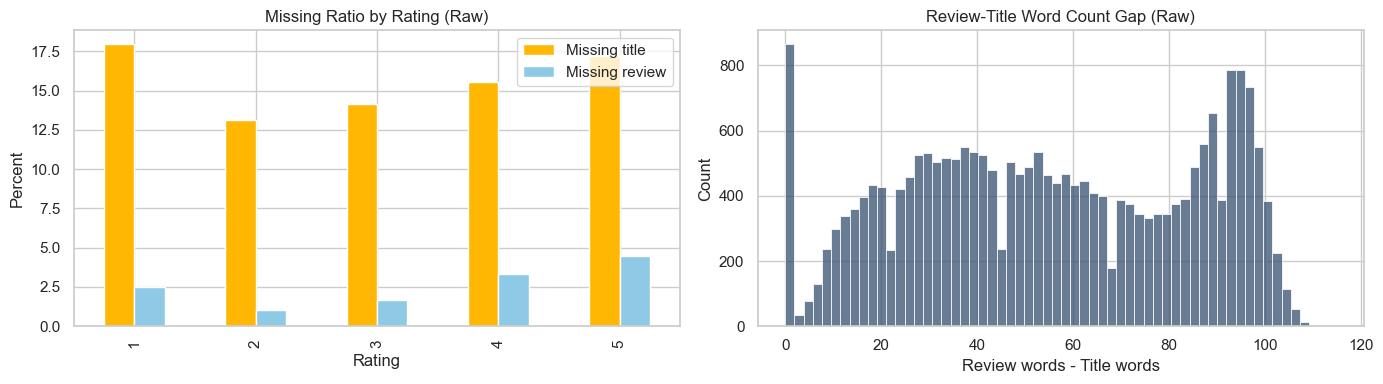

In [13]:
rating_clean = pd.to_numeric(raw_original["Rating"], errors="coerce")
missing_title_flag = raw_original["Title"].fillna("").astype(str).str.strip().eq("")
missing_review_flag = raw_original["Review Text"].fillna("").astype(str).str.strip().eq("")

missing_by_rating = pd.DataFrame({
    "rating": rating_clean,
    "missing_title": missing_title_flag.astype(int),
    "missing_review": missing_review_flag.astype(int),
}).dropna()
missing_by_rating["rating"] = missing_by_rating["rating"].astype(int)

missing_ratio = missing_by_rating.groupby("rating")[["missing_title", "missing_review"]].mean() * 100
display(missing_ratio.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing_ratio.plot(kind="bar", ax=axes[0], color=["#ffb703", "#8ecae6"])
axes[0].set_title("Missing Ratio by Rating (Raw)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Percent")
axes[0].legend(["Missing title", "Missing review"], loc="upper right")

title_word_count_raw = raw_original["Title"].fillna("").astype(str).str.split().str.len()
review_word_count_raw = raw_original["Review Text"].fillna("").astype(str).str.split().str.len()
word_count_gap = (review_word_count_raw - title_word_count_raw).clip(lower=0)
sns.histplot(word_count_gap, bins=60, ax=axes[1], color="#355070")
axes[1].set_title("Review-Title Word Count Gap (Raw)")
axes[1].set_xlabel("Review words - Title words")
axes[1].set_ylabel("Count")

plt.tight_layout()
save_current_figure("raw_missing_and_token_gap.png")
plt.show()

## 2) After Prepare Data (Focus on Title + Review Text + Rating)

In [7]:
df_loaded = load_raw_data()
df_clean = clean_data(df_loaded.copy())
df_after = create_full_text(df_clean.copy())

pipeline_summary = pd.DataFrame([
    {"stage": "raw_original_csv", "rows": len(raw_original)},
    {"stage": "load_raw_data_renamed", "rows": len(df_loaded)},
    {"stage": "clean_data", "rows": len(df_clean)},
    {"stage": "final_dataset_for_modeling", "rows": len(df_after)},
])
pipeline_summary["removed_vs_prev"] = (pipeline_summary["rows"].shift(1) - pipeline_summary["rows"]).fillna(0).astype(int)
pipeline_summary["kept_pct_vs_raw"] = (pipeline_summary["rows"] / pipeline_summary.loc[0, "rows"] * 100).round(2)

display(pipeline_summary)

[2026-04-06 21:13:56] INFO - Loaded raw data: 23486 rows
[2026-04-06 21:13:56] INFO - After dropping missing review_text/rating: 22641 rows (removed 845)
[2026-04-06 21:13:56] INFO - After deduplication: 22636 rows (removed 5)
[2026-04-06 21:13:56] INFO - After removing short reviews (<3 tokens): 22628 rows (removed 8)


,stage,rows,removed_vs_prev,kept_pct_vs_raw
0,raw_original_csv,23486,0,100.00
1,load_raw_data_renamed,23486,0,100.00
2,clean_data,22628,858,96.35
3,final_dataset_for_modeling,22628,0,96.35


In [24]:
after_focus = df_after[["title", "review_text", "rating"]].copy()

after_profile = pd.DataFrame({
    "dtype": after_focus.dtypes.astype(str),
    "missing": after_focus.isna().sum(),
    "missing_pct": (after_focus.isna().mean() * 100).round(2),
    "n_unique": after_focus.nunique(dropna=True),
}).sort_values(["missing", "n_unique"], ascending=[False, False])

display(after_profile)
display(after_focus.head(5))

,dtype,missing,missing_pct,n_unique
review_text,object,0,0.0,22626
title,object,0,0.0,13988
rating,int32,0,0.0,5


,title,review_text,rating
0,,Absolutely wonderful - silky and sexy and comf...,4
1,,Love this dress! it's sooo pretty. i happened ...,5
2,Some major design flaws,I had such high hopes for this dress and reall...,3
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5
4,Flattering shirt,This shirt is very flattering to all due to th...,5


Saved figure: outputs\figures\eda\after_prepare_rating_comparison.png


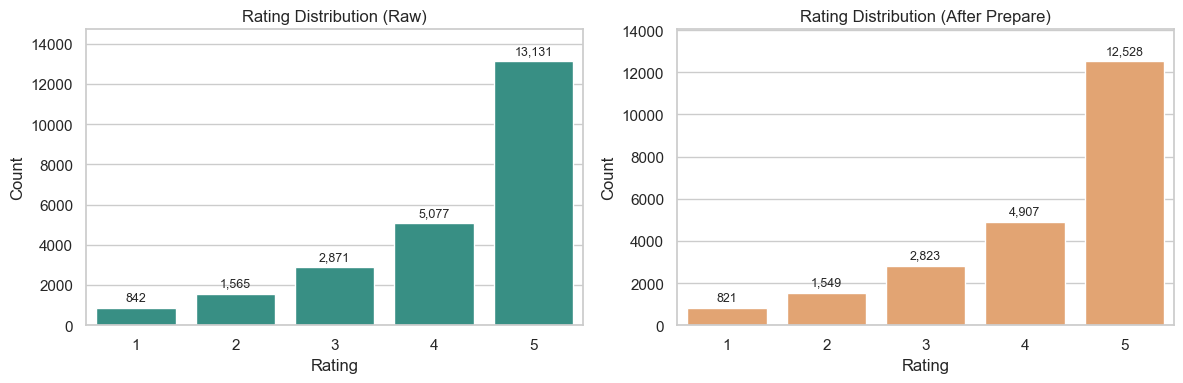

In [16]:
rating_raw = pd.to_numeric(raw_original["Rating"], errors="coerce").dropna().astype(int)
rating_after = pd.to_numeric(df_after["rating"], errors="coerce").dropna().astype(int)

rating_order = sorted(set(rating_raw.unique()).union(set(rating_after.unique())))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=rating_raw, order=rating_order, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Rating Distribution (Raw)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

sns.countplot(x=rating_after, order=rating_order, ax=axes[1], color="#f4a261")
axes[1].set_title("Rating Distribution (After Prepare)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")

for ax in axes:
    max_height = 0
    for patch in ax.patches:
        height = patch.get_height()
        max_height = max(max_height, height)
        ax.annotate(
            f"{int(height):,}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
        )
    if max_height > 0:
        ax.set_ylim(0, max_height * 1.12)

plt.tight_layout()
save_current_figure("after_prepare_rating_comparison.png")
plt.show()

,before_prepare,after_prepare
count,23486.000000,22628.000000
mean,58.030869,60.221363
std,30.176433,28.516968
min,0.000000,3.000000
50%,57.000000,59.000000
75%,87.000000,88.000000
90%,98.000000,98.000000
95%,101.000000,101.000000
max,115.000000,115.000000


Saved figure: outputs\figures\eda\token_length_before_after_prepare.png


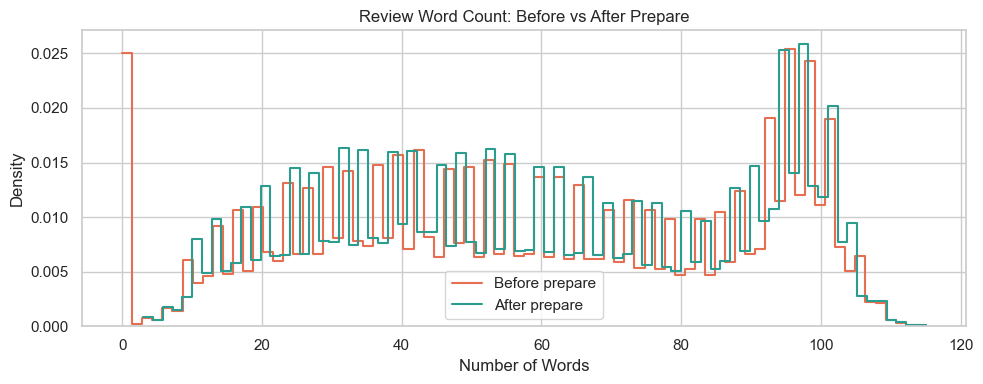

In [14]:
before_word_count = raw_original["Review Text"].fillna("").astype(str).str.split().str.len()
after_word_count = df_after["review_text"].fillna("").astype(str).str.split().str.len()

compare_len = pd.DataFrame({
    "before_prepare": before_word_count.describe(percentiles=[0.5, 0.75, 0.9, 0.95]),
    "after_prepare": after_word_count.describe(percentiles=[0.5, 0.75, 0.9, 0.95]),
})
display(compare_len)

plt.figure(figsize=(10, 4))
sns.histplot(before_word_count, bins=80, color="#e76f51", label="Before prepare", stat="density", element="step", fill=False)
sns.histplot(after_word_count, bins=80, color="#2a9d8f", label="After prepare", stat="density", element="step", fill=False)
plt.title("Review Word Count: Before vs After Prepare")
plt.xlabel("Number of Words")
plt.legend()
plt.tight_layout()
save_current_figure("token_length_before_after_prepare.png")
plt.show()

## 3) Prepared Train/Val/Test Splits (Title + Review + Rating)

In [9]:
splits_dir = Path(config.DATA_SPLITS_DIR)
split_paths = {name: splits_dir / f"{name}.csv" for name in ["train", "val", "test"]}
missing_split_files = [str(path) for path in split_paths.values() if not path.exists()]

if missing_split_files:
    print("Missing split files:")
    for p in missing_split_files:
        print(" -", p)
    print("Run: python scripts/prepare_data.py")
    split_frames = {}
else:
    split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}
    for name, frame in split_frames.items():
        print(f"{name}: {frame.shape}")

train: (15839, 12)
val: (3394, 12)
test: (3395, 12)


In [28]:
if not split_frames:
    print("No split files loaded.")
else:
    split_size_table = pd.DataFrame({
        name: {"rows": len(df), "ratio_pct": round(len(df) / len(df_after) * 100, 2)}
        for name, df in split_frames.items()
    }).T
    display(split_size_table)

    expected_cols = ["title", "review_text", "rating"]
    for name, df in split_frames.items():
        missing_cols = [c for c in expected_cols if c not in df.columns]
        print(f"{name} missing expected columns: {missing_cols if missing_cols else 'None'}")

,rows,ratio_pct
train,15839.0,70.0
val,3394.0,15.0
test,3395.0,15.0


train missing expected columns: None
val missing expected columns: None
test missing expected columns: None


,train,val,test
rating,,,
1,575,123,123
2,1084,233,232
3,1976,423,424
4,3435,736,736
5,8769,1879,1880


,train,val,test
rating,,,
1,3.63,3.62,3.62
2,6.84,6.87,6.83
3,12.48,12.46,12.49
4,21.69,21.69,21.68
5,55.36,55.36,55.38


Saved figure: outputs\figures\eda\split_rating_count_ratio.png


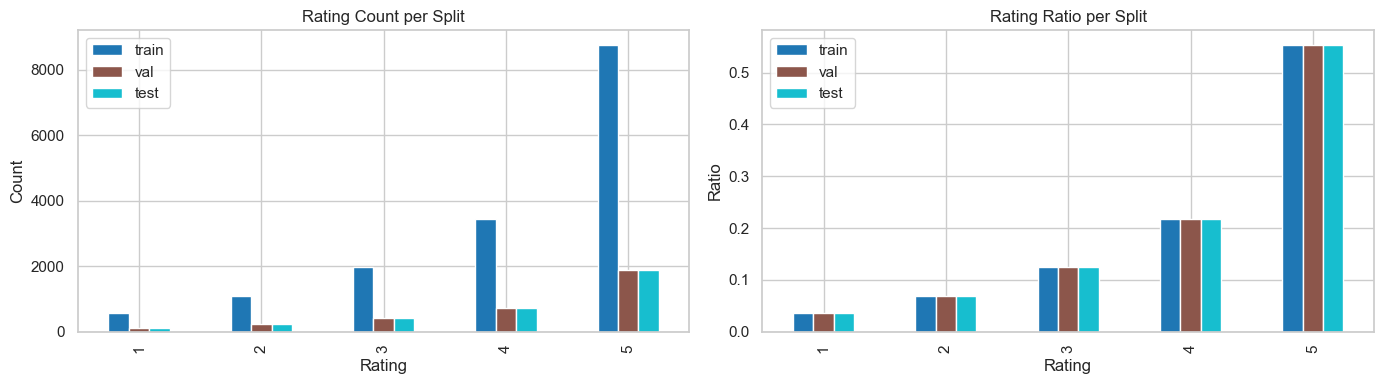

In [29]:
if not split_frames:
    print("No split files loaded.")
else:
    rating_dist = pd.concat(
        [pd.to_numeric(df["rating"], errors="coerce").dropna().astype(int).value_counts().sort_index().rename(name)
         for name, df in split_frames.items()],
        axis=1
    ).fillna(0).astype(int)

    rating_prop = rating_dist.div(rating_dist.sum(axis=0), axis=1).round(4)

    display(rating_dist)
    display((rating_prop * 100).round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    rating_dist.plot(kind="bar", ax=axes[0], colormap="tab10")
    axes[0].set_title("Rating Count per Split")
    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Count")

    rating_prop.plot(kind="bar", ax=axes[1], colormap="tab10")
    axes[1].set_title("Rating Ratio per Split")
    axes[1].set_xlabel("Rating")
    axes[1].set_ylabel("Ratio")

    plt.tight_layout()
    save_current_figure("split_rating_count_ratio.png")
    plt.show()

,rows,review_mean_words,review_median_words,review_p95_words,title_mean_words,title_median_words,title_p95_words
split,,,,,,,
train,15839,60.40,59,101,2.92,3,7
val,3394,58.90,56,101,2.89,3,7
test,3395,60.71,60,102,2.88,3,7


Saved figure: outputs\figures\eda\split_title_review_token_length.png


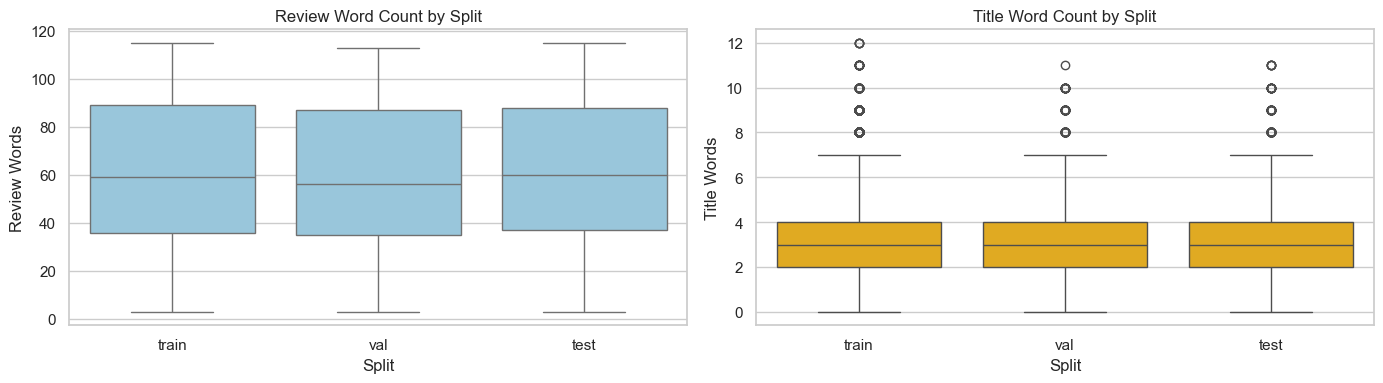

In [15]:
if not split_frames:
    print("No split files loaded.")
else:
    stats_rows = []
    review_length_long = []
    title_length_long = []

    for name, df in split_frames.items():
        review_word_count = df["review_text"].fillna("").astype(str).str.split().str.len()
        title_word_count = df["title"].fillna("").astype(str).str.split().str.len()

        stats_rows.append({
            "split": name,
            "rows": len(df),
            "review_mean_words": round(review_word_count.mean(), 2),
            "review_median_words": int(review_word_count.median()),
            "review_p95_words": int(review_word_count.quantile(0.95)),
            "title_mean_words": round(title_word_count.mean(), 2),
            "title_median_words": int(title_word_count.median()),
            "title_p95_words": int(title_word_count.quantile(0.95)),
        })

        review_length_long.append(pd.DataFrame({"split": name, "word_count": review_word_count}))
        title_length_long.append(pd.DataFrame({"split": name, "word_count": title_word_count}))

    length_stats = pd.DataFrame(stats_rows).set_index("split")
    display(length_stats)

    review_length_long_df = pd.concat(review_length_long, ignore_index=True)
    title_length_long_df = pd.concat(title_length_long, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=review_length_long_df, x="split", y="word_count", ax=axes[0], color="#8ecae6")
    axes[0].set_title("Review Word Count by Split")
    axes[0].set_xlabel("Split")
    axes[0].set_ylabel("Review Words")

    sns.boxplot(data=title_length_long_df, x="split", y="word_count", ax=axes[1], color="#ffb703")
    axes[1].set_title("Title Word Count by Split")
    axes[1].set_xlabel("Split")
    axes[1].set_ylabel("Title Words")

    plt.tight_layout()
    save_current_figure("split_title_review_token_length.png")
    plt.show()

## 4) Quick Checklist
- Raw data profile checked for `Title`, `Review Text`, `Rating`.
- Preprocessing impact quantified (rows kept/removed).
- Raw vs after-prepare rating distribution verified.
- Train/val/test split quality verified for `rating`, `title`, `review_text`.
- Figures exported to `outputs/figures/eda` for report embedding.